In [1]:
# 7-21-2026

In [2]:
# formalize all of the observations about the transfer matrix
#   such as the asymmetry, on vs off diag discrepncy, distributions, etc

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns

In [5]:
true_matrix = pd.read_csv("transfer-matrix/rf_transfer_matrix.csv")
true_matrix.set_index("Unnamed: 0", inplace=True)
true_matrix.index.name = None
true_matrix.index = true_matrix.index.astype(int)
true_matrix.columns = true_matrix.columns.astype(int)
true_matrix.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.392727,0.291660,0.127238,0.058840,0.214817,0.084705,0.149056,0.182358,0.173877,0.026375,...,0.228505,0.243433,0.149609,0.275203,0.112525,-0.011557,0.116862,0.158796,0.025454,0.029928
1,0.142172,0.395760,0.030643,0.010376,0.180707,0.064432,0.056092,0.128808,0.097788,0.039590,...,0.167477,0.032806,0.029704,0.193033,0.055264,0.066550,0.108203,0.199762,0.023240,-0.037710
2,0.196600,0.214445,0.368173,0.023968,0.207323,0.140139,0.172990,0.231019,0.156741,0.057226,...,0.197402,0.223793,0.121457,0.248807,0.134485,0.053503,-0.005610,0.253965,0.031899,0.059566
4,0.235489,0.227173,0.127394,0.410382,0.215954,0.186207,0.125068,0.196603,0.165264,0.034514,...,0.178055,0.245668,0.147579,0.284360,0.217076,-0.003941,0.037643,0.306750,0.137154,0.020968
5,0.190803,0.206530,0.097887,0.087230,0.464604,0.144950,0.159361,0.204884,0.264641,0.104493,...,0.197195,0.232923,0.117228,0.292623,0.170687,-0.020694,0.115293,0.297271,0.067951,0.051770


In [14]:
diff = abs((true_matrix - true_matrix.T).to_numpy())
np.fill_diagonal(diff, np.nan)
avg_asymmetry = np.nanmean(diff)
asymmetry_std = np.nanstd(diff)
print(f"average off diag asymmetry: {avg_asymmetry:.4f}")
print(f"off diag asymmetry std: {asymmetry_std:.4f}")

average off diag asymmetry: 0.0748
off diag asymmetry std: 0.0569


In [15]:
# on diag values
on_diag = np.diag(true_matrix.to_numpy())
on_diag_mean = np.mean(on_diag)
on_diag_std = np.std(on_diag)

# off diag values
vals = true_matrix.to_numpy().copy()
np.fill_diagonal(vals, np.nan)
off_diag_mean = np.nanmean(vals)
off_diag_std = np.nanstd(vals)

print(f"on diag mean: {on_diag_mean:.4f}")
print(f"on diag std: {on_diag_std:.4f}")
print(f"off diag mean: {off_diag_mean:.4f}")
print(f"off diag std: {off_diag_std:.4f}")

on diag mean: 0.3997
on diag std: 0.0745
off diag mean: 0.0931
off diag std: 0.0828


In [18]:
# find highest off diag entry per row
vals = true_matrix.to_numpy().copy()
np.fill_diagonal(vals, np.nan)

row_max_idx = np.nanargmax(vals, axis=1)
row_max_val = np.nanmax(vals, axis=1)

cols = true_matrix.columns.to_numpy()

for row_id, max_col_pos, max_val in zip(true_matrix.index, row_max_idx, row_max_val):
    print(f"row: {row_id}, highest off diag col: {cols[max_col_pos]}, transferability: {max_val:.4f}")

row: 0, highest off diag col: 1, transferability: 0.2917
row: 1, highest off diag col: 46, transferability: 0.1998
row: 2, highest off diag col: 25, transferability: 0.2989
row: 4, highest off diag col: 46, transferability: 0.3068
row: 5, highest off diag col: 46, transferability: 0.2973
row: 6, highest off diag col: 46, transferability: 0.3211
row: 7, highest off diag col: 25, transferability: 0.2240
row: 8, highest off diag col: 46, transferability: 0.2401
row: 11, highest off diag col: 25, transferability: 0.3726
row: 12, highest off diag col: 1, transferability: 0.1758
row: 13, highest off diag col: 37, transferability: 0.2438
row: 16, highest off diag col: 39, transferability: 0.1837
row: 18, highest off diag col: 37, transferability: 0.2771
row: 19, highest off diag col: 37, transferability: 0.2040
row: 20, highest off diag col: 37, transferability: 0.3136
row: 21, highest off diag col: 16, transferability: 0.2468
row: 22, highest off diag col: 37, transferability: 0.2778
row: 23

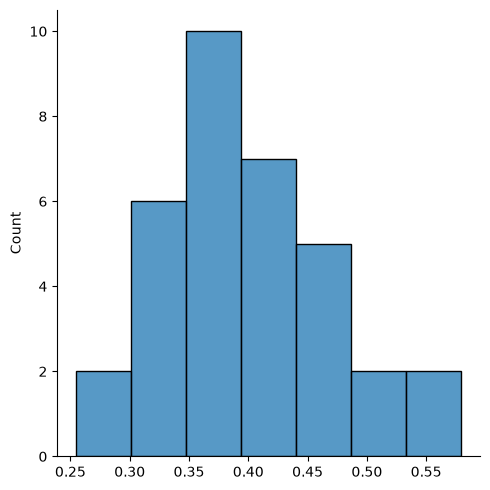

In [23]:
sns.displot(on_diag, kde=False, bins=7)

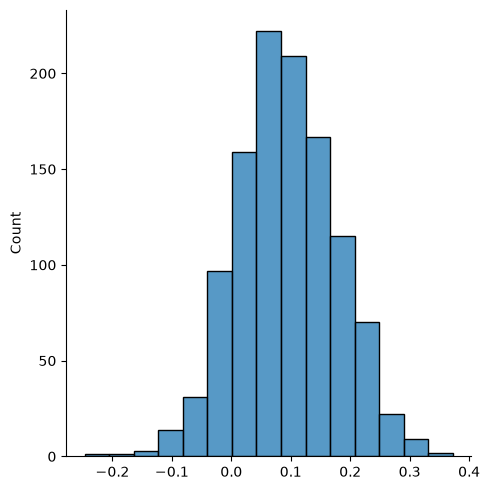

In [26]:
off_diag_vals = vals[~np.isnan(vals)]
sns.displot(off_diag_vals, kde=False, bins=15)

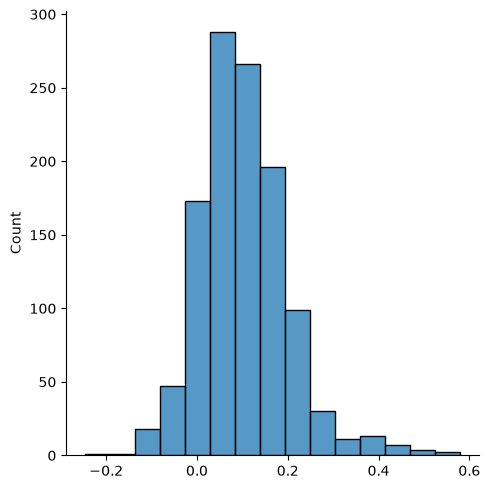

In [28]:
full_vals = true_matrix.to_numpy().flatten()
sns.displot(full_vals, kde=False, bins=15)

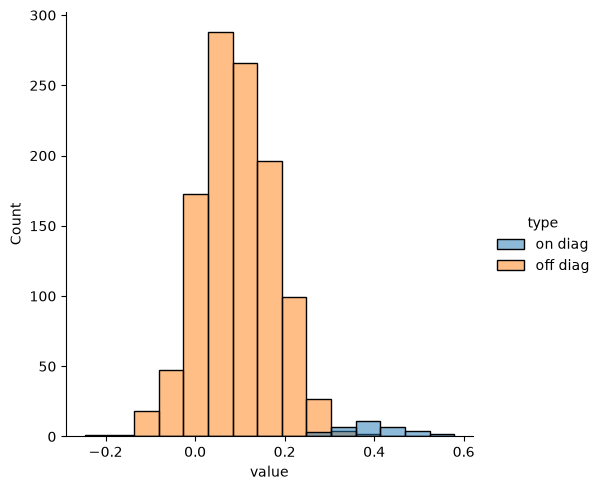

In [31]:
n = true_matrix.shape[0]
mask = np.eye(n, dtype=bool)

full_vals = true_matrix.to_numpy().flatten()
diag_label = np.where(mask.flatten(), "on diag", "off diag")

plot_df = pd.DataFrame({"value": full_vals, "type": diag_label})

sns.displot(data=plot_df, x="value", hue="type", kde=False, bins=15)

In [33]:
embeddings = pd.read_csv("probing/domain_embeddings_v4.csv")
embeddings

,domain_id,e_0,e_1,e_2,e_3,e_4,e_5,e_6,e_7,e_8,src_bias,tgt_bias
0,0,0.044920,-0.140614,-0.092586,0.038657,0.091209,0.044721,-0.177195,0.017328,0.141784,0.204292,-0.017042
1,1,0.044615,-0.182949,-0.102645,0.036313,0.095344,0.107567,-0.248821,-0.000363,0.227570,0.176388,0.026637
2,2,0.065594,-0.110857,-0.039893,0.000854,0.076925,0.008618,-0.111971,-0.082349,0.096454,0.221703,-0.044998
3,4,0.081379,-0.068263,-0.103002,-0.023489,0.136152,0.028229,-0.148741,-0.059863,0.195213,0.231726,-0.063666
4,5,0.058112,-0.131804,-0.096756,0.065104,0.096903,0.066202,-0.164116,0.035039,0.129189,0.204279,-0.007497
5,6,0.031337,-0.078988,-0.079885,-0.028435,0.096454,0.022641,-0.151283,-0.107068,0.188521,0.203711,-0.052326
6,7,0.014070,-0.052960,-0.034756,-0.003813,0.026460,0.006066,-0.144582,-0.040931,0.106742,0.192011,-0.040780
7,8,0.006491,-0.177796,-0.116224,0.055101,0.083911,0.038436,-0.204769,-0.027186,0.193486,0.194318,0.001937
8,11,0.035975,-0.159781,-0.092753,0.021536,0.060885,0.046934,-0.127037,0.082622,0.108953,0.201887,-0.013454
9,12,0.207878,-0.076214,-0.010489,-0.033233,0.112294,0.160409,-0.162571,0.014760,0.106880,0.202830,-0.032079


In [34]:
# flatten e[0:3], e[3:6], e[6:9] values

In [35]:
atmo_cols = [c for c in embeddings.columns if c.startswith("e_")][0:3]
fire_cols = [c for c in embeddings.columns if c.startswith("e_")][6:9]
ground_cols = [c for c in embeddings.columns if c.startswith("e_")][3:6]

In [37]:
fire_cols

['e_6', 'e_7', 'e_8']

In [38]:
atmo_vals = embeddings[atmo_cols].to_numpy().flatten()
fire_vals = embeddings[fire_cols].to_numpy().flatten()
ground_vals = embeddings[ground_cols].to_numpy().flatten()

In [40]:
print(f"atmo embedding mean: {atmo_vals.mean():.4f}")
print(f"ground embedding mean: {ground_vals.mean():.4f}")
print(f"fire embedding mean: {fire_vals.mean():.4f}")

atmo embedding mean: -0.0364
ground embedding mean: 0.0447
fire embedding mean: -0.0159


In [43]:
print(f"atmo embedding mag mean: {np.abs(atmo_vals).mean():.4f}") # abs before mean so it doesnt just take the abs of the mean
print(f"ground embedding mag mean: {np.abs(ground_vals).mean():.4f}")
print(f"fire embedding mag mean: {np.abs(fire_vals).mean():.4f}")

atmo embedding mag mean: 0.0730
ground embedding mag mean: 0.0513
fire embedding mag mean: 0.1245


In [44]:
print(f"atmo embedding std: {atmo_vals.std():.4f}")
print(f"ground embedding std: {ground_vals.std():.4f}")
print(f"fire embedding std: {fire_vals.std():.4f}")

atmo embedding std: 0.0814
ground embedding std: 0.0480
fire embedding std: 0.1448


In [45]:
def branch_sq_dist(df, cols):
    x = df[cols].to_numpy()
    diffs = x[:, None, :] - x[None, :, :]  # shape (n, n, d)
    return (diffs ** 2).sum(axis=2)  # shpe (n, n), sq dist per pair

atmo_sq = branch_sq_dist(embeddings, atmo_cols)
ground_sq = branch_sq_dist(embeddings, ground_cols)
fire_sq = branch_sq_dist(embeddings, fire_cols)

In [46]:
total_sq = atmo_sq + ground_sq + fire_sq

n = len(embeddings)
mask = ~np.eye(n, dtype=bool)  # drop diagonal, self-pairs are 0

In [ ]:
atmo_frac = (atmo_sq[mask] / total_sq[mask]).mean()
ground_frac = (ground_sq[mask] / total_sq[mask]).mean()
fire_frac = (fire_sq[mask] / total_sq[mask]).mean()

print(f"atmo avg contribution: {atmo_frac:.4f}")
print(f"ground avg contribution: {ground_frac:.4f}")
print(f"fire avg contribution: {fire_frac:.4f}")

# these all ad up to 1, its basically a avg frac of distance that each branch contributes to

atmo avg contribution: 0.3540
ground avg contribution: 0.2216
fire avg contribution: 0.4244


In [48]:
atmo_frac_std = (atmo_sq[mask] / total_sq[mask]).std()
ground_frac_std = (ground_sq[mask] / total_sq[mask]).std()
fire_frac_std = (fire_sq[mask] / total_sq[mask]).std()

print(f"atmo contribution std: {atmo_frac_std:.4f}")
print(f"ground contribution std: {ground_frac_std:.4f}")
print(f"fire contribution std: {fire_frac_std:.4f}")

atmo contribution std: 0.2143
ground contribution std: 0.1510
fire contribution std: 0.2370
